This file loads soil data into a dataframe to visualize the first map of microplastic concentrations in Trondheim

In [2]:
from pathlib import Path

import pandas as pd

# Read the workbook from the Data folder into a new DataFrame.
excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
soil_autolabel_df = pd.read_excel(excel_file)

# Rename position columns for autolabel data.
soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

# Build Sample_ID from image values (drop S prefix, leading zeros, and file suffix).
sample_id = (
    soil_autolabel_df["image"]
    .str.extract(r"S0*([0-9]+)", expand=False)
    .astype("Int64")
)

if "Sample_ID" in soil_autolabel_df.columns:
    soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])

soil_autolabel_df.insert(
    soil_autolabel_df.columns.get_loc("image"),
    "Sample_ID",
    sample_id,
)

print(f"Loaded {soil_autolabel_df.shape[0]} rows and {soil_autolabel_df.shape[1]} columns")
soil_autolabel_df.head()

Loaded 61 rows and 14 columns


,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0
1,3,S0003_NR.png,1,2790,2232,19,12,166,31.6860,460.7,584.3,348.5,1.68,1.0.0
2,5,S0005_NR.png,1,2393,1837,19,13,194,31.5871,496.4,599.3,379.0,1.58,1.0.0
3,7,S0007_NR.png,1,2704,2370,9,6,46,31.4438,240.6,259.3,157.2,1.65,1.0.0
4,13,S0013_NR.png,1,1147,1533,14,8,87,31.6065,332.7,412.1,221.2,1.86,1.0.0


In [3]:
# Create a DataFrame from the ArcGIS Excel file.
arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
soil_arcgis_df = pd.read_excel(arcgis_file)

# Rename coordinate columns for ArcGIS data.
soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

print(f"Loaded {soil_arcgis_df.shape[0]} rows and {soil_arcgis_df.shape[1]} columns")
soil_arcgis_df.head()

Loaded 149 rows and 16 columns


,OBJECTID,GlobalID,place_name,Sample_ID,Date,Region,Notes_Environment_description,Potential plastic sources,Macroplastics observed,Corridor,CreationDate,Creator,EditDate,Editor,x (long),y (lat)
0,4,945cc581-79da-43ff-b98d-be4a5ee18854,Blåbærstupet,33,2026-07-06 08:52:54.373,NaN,"Near the fjord, and pirbadet. Nice view, took ...",NaN,NaN,NaN,2026-07-06 08:56:11.307,senasm_NTNU_2026,2026-07-06 08:56:11.307,senasm_NTNU_2026,10.393289,63.437870
1,5,e06d3d13-f66d-4600-bc4a-5a2101f2d11a,Blåbærstupet,34,2026-07-06 08:58:25.990,NaN,Bad surface. Steinete underlag. Lenger ut på ø...,NaN,NaN,NaN,2026-07-06 09:00:34.346,senasm_NTNU_2026,2026-07-23 11:09:22.922,senasm_NTNU_2026,10.393090,63.437827
2,6,89f31e09-0900-4840-bf5c-85552d9b29c5,Tømmerholt,35,2026-07-06 09:44:18.772,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 09:44:21.112,senasm_NTNU_2026,2026-07-28 12:08:41.925,senasm_NTNU_2026,10.474053,63.390331
3,7,dcdcbd55-ab5d-4aa0-9a7c-6fa9c4deda52,Tømmerholt,36,2026-07-06 09:49:43.006,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 09:49:45.957,senasm_NTNU_2026,2026-07-28 12:08:48.678,senasm_NTNU_2026,10.476196,63.390851
4,8,3cba7106-9609-4837-aa45-06c720e12df1,Tømmerholt,37,2026-07-06 10:00:00.000,NaN,Forest area near water,NaN,NaN,NaN,2026-07-06 10:04:29.694,frehau_NTNU_2026,2026-07-28 12:08:50.742,senasm_NTNU_2026,10.479347,63.392105


In [4]:
# Start with the first DataFrame and add matching coordinates from the second DataFrame.
coords_by_sample = (
    soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
    .dropna(subset=["Sample_ID"])
    .drop_duplicates(subset=["Sample_ID"], keep="first")
)

soil_autolabel_with_coords_df = soil_autolabel_df.merge(
    coords_by_sample,
    on="Sample_ID",
    how="left",
)

print(
    f"Created dataframe with {soil_autolabel_with_coords_df.shape[0]} rows and "
    f"{soil_autolabel_with_coords_df.shape[1]} columns"
)
soil_autolabel_with_coords_df.head()

Created dataframe with 61 rows and 16 columns


,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version,x (long),y (lat)
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0,10.405113,63.419756
1,3,S0003_NR.png,1,2790,2232,19,12,166,31.6860,460.7,584.3,348.5,1.68,1.0.0,10.405279,63.419811
2,5,S0005_NR.png,1,2393,1837,19,13,194,31.5871,496.4,599.3,379.0,1.58,1.0.0,10.397522,63.421440
3,7,S0007_NR.png,1,2704,2370,9,6,46,31.4438,240.6,259.3,157.2,1.65,1.0.0,10.396640,63.423140
4,13,S0013_NR.png,1,1147,1533,14,8,87,31.6065,332.7,412.1,221.2,1.86,1.0.0,10.386079,63.429519


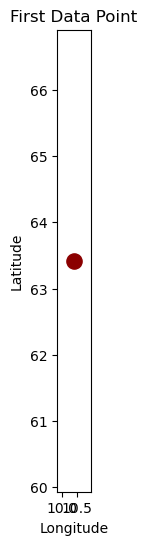

,Sample_ID,image,particle,x (pos),y (pos),w,h,area_px,um_per_px,equiv_diam_um,length_um,width_um,aspect_ratio,tool_version,x (long),y (lat),geometry
0,2,S0002_NR.png,1,2087,865,61,65,2076,31.4126,1615.0,2449.8,1243.9,1.97,1.0.0,10.405113,63.419756,POINT (10.40511 63.41976)


In [5]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

if "soil_autolabel_with_coords_df" not in globals():
    excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
    soil_autolabel_df = pd.read_excel(excel_file)
    soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

    sample_id = (
        soil_autolabel_df["image"]
        .str.extract(r"S0*([0-9]+)", expand=False)
        .astype("Int64")
    )
    if "Sample_ID" in soil_autolabel_df.columns:
        soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])
    soil_autolabel_df.insert(soil_autolabel_df.columns.get_loc("image"), "Sample_ID", sample_id)

    arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
    soil_arcgis_df = pd.read_excel(arcgis_file)
    soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

    coords_by_sample = (
        soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
        .dropna(subset=["Sample_ID"])
        .drop_duplicates(subset=["Sample_ID"], keep="first")
    )
    soil_autolabel_with_coords_df = soil_autolabel_df.merge(
        coords_by_sample,
        on="Sample_ID",
        how="left",
    )

first_point_df = soil_autolabel_with_coords_df.dropna(subset=["x (long)", "y (lat)"]).iloc[[0]].copy()

first_point_gdf = gpd.GeoDataFrame(
    first_point_df,
    geometry=gpd.points_from_xy(first_point_df["x (long)"], first_point_df["y (lat)"]),
    crs="EPSG:4326",
)

ax = first_point_gdf.plot(figsize=(6, 6), color="darkred", markersize=120)
ax.set_title("First Data Point")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

first_point_gdf

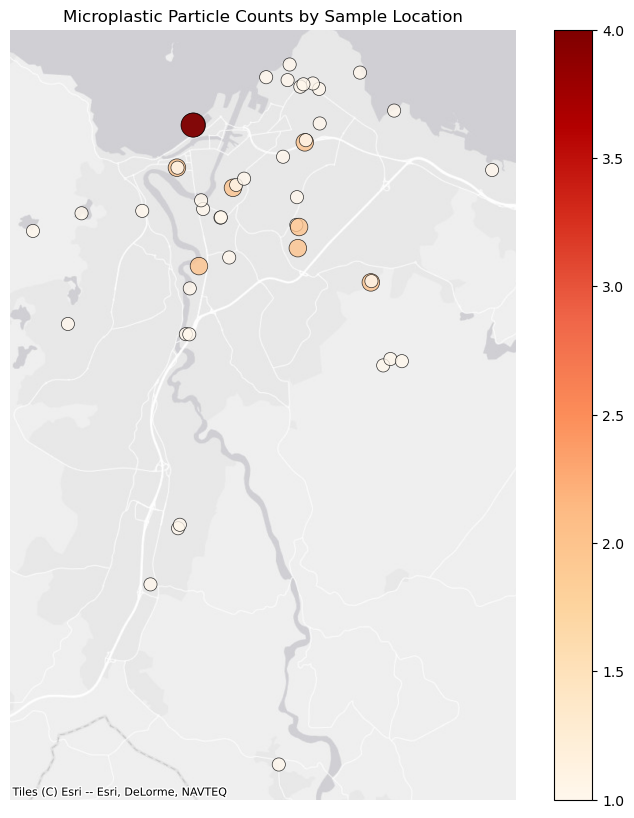

,Sample_ID,x (long),y (lat),particle_count,geometry
0,2,10.405113,63.419756,1,POINT (10.40511 63.41976)
1,3,10.405279,63.419811,1,POINT (10.40528 63.41981)
2,5,10.397522,63.421440,1,POINT (10.39752 63.42144)
3,7,10.396640,63.423140,1,POINT (10.39664 63.42314)
4,13,10.386079,63.429519,2,POINT (10.38608 63.42952)


In [6]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

if "soil_autolabel_with_coords_df" not in globals():
    excel_file = Path.cwd() / "Data" / "Soil_Autolabel_Data.xlsx"
    soil_autolabel_df = pd.read_excel(excel_file)
    soil_autolabel_df = soil_autolabel_df.rename(columns={"x": "x (pos)", "y": "y (pos)"})

    sample_id = (
        soil_autolabel_df["image"]
        .str.extract(r"S0*([0-9]+)", expand=False)
        .astype("Int64")
    )
    if "Sample_ID" in soil_autolabel_df.columns:
        soil_autolabel_df = soil_autolabel_df.drop(columns=["Sample_ID"])
    soil_autolabel_df.insert(soil_autolabel_df.columns.get_loc("image"), "Sample_ID", sample_id)

    arcgis_file = Path.cwd() / "Data" / "Soil_ArcGis_Data.xlsx"
    soil_arcgis_df = pd.read_excel(arcgis_file)
    soil_arcgis_df = soil_arcgis_df.rename(columns={"x": "x (long)", "y": "y (lat)"})

    coords_by_sample = (
        soil_arcgis_df[["Sample_ID", "x (long)", "y (lat)"]]
        .dropna(subset=["Sample_ID"])
        .drop_duplicates(subset=["Sample_ID"], keep="first")
    )
    soil_autolabel_with_coords_df = soil_autolabel_df.merge(
        coords_by_sample,
        on="Sample_ID",
        how="left",
    )

soil_particle_counts_gdf = (
    soil_autolabel_with_coords_df
    .dropna(subset=["x (long)", "y (lat)"])
    .groupby(["Sample_ID", "x (long)", "y (lat)"], as_index=False)["particle"]
    .nunique()
    .rename(columns={"particle": "particle_count"})
)

soil_particle_counts_gdf = gpd.GeoDataFrame(
    soil_particle_counts_gdf,
    geometry=gpd.points_from_xy(
        soil_particle_counts_gdf["x (long)"],
        soil_particle_counts_gdf["y (lat)"],
    ),
    crs="EPSG:4326",
)

soil_particle_counts_webmerc = soil_particle_counts_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
soil_particle_counts_webmerc.plot(
    ax=ax,
    column="particle_count",
    cmap="OrRd",
    legend=True,
    markersize=soil_particle_counts_webmerc["particle_count"] * 70 + 20,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("Microplastic Particle Counts by Sample Location")
ax.set_axis_off()
plt.show()

soil_particle_counts_gdf.head()

In [7]:
from pathlib import Path

output_dir = Path('Maps')
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / 'soil_particle_counts_map.png', dpi=300, bbox_inches='tight')
print(f"Map exported to: {output_dir / 'soil_particle_counts_map.png'}")

Map exported to: Maps/soil_particle_counts_map.png


In [9]:
from pathlib import Path

import pandas as pd

agriculture_file = Path.cwd() / "Data" / "Team_Agriculture_Sample_Data.xlsx"
agriculture_df = pd.read_excel(agriculture_file, sheet_name="Data", header=[0, 1])

# Normalize the multi-level Excel header to single clean column names.
agriculture_df.columns = [
    col[0] if str(col[1]).startswith("Unnamed") else f"{col[0]} | {col[1]}"
    for col in agriculture_df.columns
]

print(f"Loaded {agriculture_df.shape[0]} rows and {agriculture_df.shape[1]} columns")
agriculture_df.head()

Loaded 128 rows and 20 columns


/Users/michaelmetzler/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/Users/michaelmetzler/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Name of Farm | Unnamed: 0_level_1,Sample ID | Unnamed: 1_level_1,Date | Unnamed: 2_level_1,Status | Unnamed: 3_level_1,Status Analysis | Unnamed: 4_level_1,What is produced | Unnamed: 5_level_1,What is produced spesific | Unnamed: 6_level_1,Weight Soil Dry [g] (added to beaker) | Unnamed: 7_level_1,Nile Red | Manual counted Plastic [n/5g],Nile Red | Data Program Counted Plastic [n/5g],Weather | Weather,Weather | Total Rain 24h,Weather | Avg. Temperature last 24h,Location | Kjøreplan,Location | Kommuner,Location | Longitude,Location | Latitude,Notes - Environment description | Unnamed: 17_level_1,Notes - Environment description | Unnamed: 18_level_1,Notes - Environment description | Unnamed: 19_level_1
0,Voll Gård,1.1,06.24.2026 14:15,Finished,Finished Nile Red,Gress,Gress,5.01,1.0,3,Rainy,4.5,12.3,Trondheim,Trondheim,NaN,NaN,No visible plastic waste,NaN,NaN
1,Voll Gård,1.2,06.24.2026 14:30,Finished,Finished Nile Red,Beite,Geit,5.02,1.0,1,Rainy,4.5,12.3,Trondheim,Trondheim,NaN,NaN,No visible plastic waste,NaN,NaN
2,Onsøyen Gård,2.1,07.01.2026 07:31,Finished,Finished Nile Red,Gress,Gress,5.10,3.0,3,sunny,0.0,14.6,Spongdal,Trondheim,10.18236,63.42836,"Høyballer, gård, parkeringsplass, veg, elv, sk...",NaN,NaN
3,Onsøyen Gård,2.2,07.01.2026 07:39,Finished,Finished Nile Red,Beite,Sau,5.08,3.0,96,sunny,0.0,14.6,Spongdal,Trondheim,10.18236,63.42836,"Høyballer, gård, parkeringsplass, veg, elv, sk...",NaN,NaN
4,Onsøyen Gård,2.3,07.01.2026 07:58,Finished,Finished Nile Red,Korn,Bygg,5.01,5.0,6,sunny,0.0,14.6,Spongdal,Trondheim,10.18236,63.42836,"Høyballer, gård, parkeringsplass, veg, elv, sk...",NaN,NaN


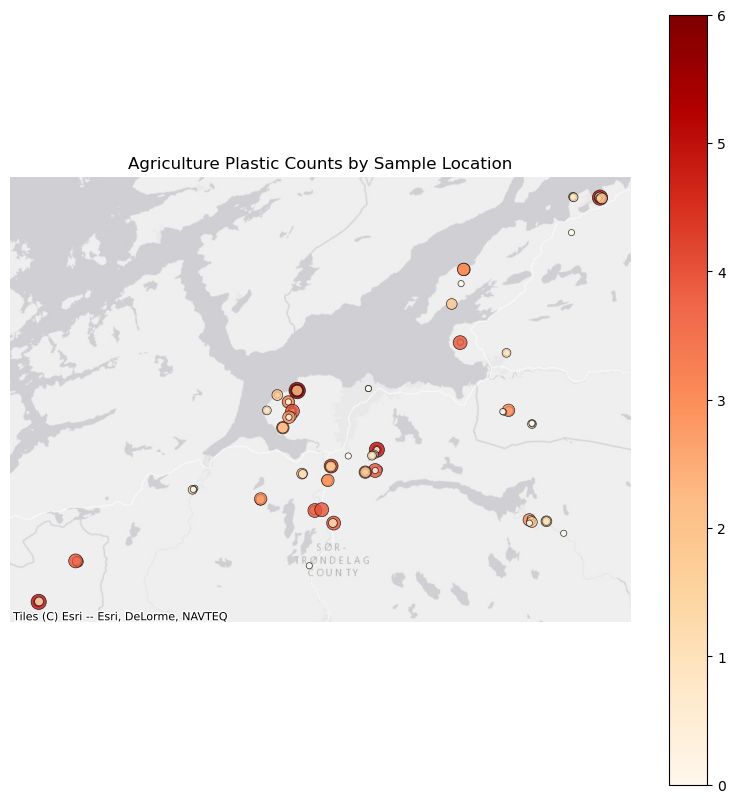

,plastic_count,longitude,latitude,geometry
2,3.0,10.18236,63.42836,POINT (10.18236 63.42836)
3,3.0,10.18236,63.42836,POINT (10.18236 63.42836)
4,6.0,10.18236,63.42836,POINT (10.18236 63.42836)
5,2.0,10.18236,63.42836,POINT (10.18236 63.42836)
6,0.0,10.10738,63.42074,POINT (10.10738 63.42074)


In [12]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

count_col = "Nile Red | Data Program Counted Plastic [n/5g]"
lon_col = "Location | Longitude"
lat_col = "Location | Latitude"

agriculture_points = (
    agriculture_df[[count_col, lon_col, lat_col]]
    .copy()
    .rename(columns={count_col: "plastic_count", lon_col: "longitude", lat_col: "latitude"})
)

agriculture_points["plastic_count"] = pd.to_numeric(agriculture_points["plastic_count"], errors="coerce")
agriculture_points["longitude"] = pd.to_numeric(agriculture_points["longitude"], errors="coerce")
agriculture_points["latitude"] = pd.to_numeric(agriculture_points["latitude"], errors="coerce")
agriculture_points = agriculture_points.dropna(subset=["plastic_count", "longitude", "latitude"]).copy()

agriculture_gdf = gpd.GeoDataFrame(
    agriculture_points,
    geometry=gpd.points_from_xy(agriculture_points["longitude"], agriculture_points["latitude"]),
    crs="EPSG:4326",
)

agriculture_webmerc = agriculture_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
agriculture_webmerc.plot(
    ax=ax,
    column="plastic_count",
    cmap="OrRd",
    legend=True,
    markersize=agriculture_webmerc["plastic_count"] * 20 + 20,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("Agriculture Plastic Counts by Sample Location")
ax.set_axis_off()
plt.show()

agriculture_gdf.head()

In [11]:
# Clean the agriculture data: if the SIC output count is >10, replace it with the manual count.
from pathlib import Path
import pandas as pd

agriculture_file = Path.cwd() / "Data" / "Team_Agriculture_Sample_Data.xlsx"
agriculture_df = pd.read_excel(agriculture_file, sheet_name="Data", header=[0, 1])


def clean_multilevel_col(col):
    left = str(col[0]).strip()
    right = str(col[1]).strip()
    if right == "" or right.startswith("Unnamed"):
        return left
    return f"{left} | {right}"


agriculture_df.columns = [clean_multilevel_col(col) for col in agriculture_df.columns]
agriculture_df.columns = [c.strip() for c in agriculture_df.columns]

manual_col = "Nile Red | Manual counted Plastic [n/5g]"
program_col = "Nile Red | Data Program Counted Plastic [n/5g]"
name_col = "Name of Farm"

agriculture_df[name_col] = agriculture_df[name_col].astype(str).str.strip()
agriculture_df[manual_col] = pd.to_numeric(agriculture_df[manual_col], errors="coerce")
agriculture_df[program_col] = pd.to_numeric(agriculture_df[program_col], errors="coerce")

mask = agriculture_df[program_col] > 10
agriculture_df.loc[mask, program_col] = agriculture_df.loc[mask, manual_col]

print(f"Rows replaced: {int(mask.sum())}")
print(
    agriculture_df.loc[
        agriculture_df[name_col] == "NABO Halgunsetvegen 117",
        [name_col, manual_col, program_col],
    ]
)

agriculture_df[[manual_col, program_col]].head(20)

Rows replaced: 2
               Name of Farm  Nile Red | Manual counted Plastic [n/5g]  \
56  NABO Halgunsetvegen 117                                       4.0   

    Nile Red | Data Program Counted Plastic [n/5g]  
56                                             4.0  


/Users/michaelmetzler/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/Users/michaelmetzler/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Nile Red | Manual counted Plastic [n/5g],Nile Red | Data Program Counted Plastic [n/5g]
0,1.0,3.0
1,1.0,1.0
2,3.0,3.0
3,3.0,3.0
4,5.0,6.0
5,2.0,2.0
6,0.0,0.0
7,2.0,2.0
8,0.0,0.0
9,1.0,1.0


In [13]:
from pathlib import Path

output_dir = Path("Maps")
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / "agriculture_plastic_counts_map.png", dpi=300, bbox_inches="tight")
print(f"Map exported to: {output_dir / 'agriculture_plastic_counts_map.png'}")

Map exported to: Maps/agriculture_plastic_counts_map.png
